In [1]:
import pandas as pd
import numpy as np

print("Python is working!")
print("Pandas version:", pd.__version__)

Python is working!
Pandas version: 3.0.2


In [7]:
import pandas as pd

file_path = "../data/online_retail.csv"

df = pd.read_csv(file_path)

print(df.head())

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [3]:
import pandas as pd

In [8]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1067371
Columns: 8


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [10]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

In [11]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [12]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [13]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 34335


In [14]:
df.dtypes

Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object

In [15]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [16]:
print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [17]:
print("Before removing duplicates:", df.shape)

df = df.drop_duplicates()

print("After removing duplicates:", df.shape)

Before removing duplicates: (1067371, 8)
After removing duplicates: (1033036, 8)


In [18]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4275
Quantity            0
InvoiceDate         0
Price               0
Customer ID    235151
Country             0
dtype: int64

In [20]:
df = df.dropna(subset=["Customer ID"])

print("Rows after removing missing CustomerID:", df.shape[0])

Rows after removing missing CustomerID: 797885


In [21]:
print(df["Quantity"].describe())


count    797885.000000
mean         12.602980
std         191.670371
min      -80995.000000
25%           2.000000
50%           5.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64


In [22]:
df = df[df["Quantity"] > 0]

print("Rows after Quantity cleaning:", df.shape[0])

Rows after Quantity cleaning: 779495


In [25]:
print(df["Price"].describe())

count    779495.000000
mean          3.218199
std          29.674823
min           0.000000
25%           1.250000
50%           1.950000
75%           3.750000
max       10953.500000
Name: Price, dtype: float64


In [27]:
df = df[df["Price"] > 0]

print("Rows after UnitPrice cleaning:", df.shape[0])

Rows after UnitPrice cleaning: 779425


In [28]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(df["InvoiceDate"].dtype)

datetime64[us]


In [29]:
print("Start Date:", df["InvoiceDate"].min())
print("End Date:", df["InvoiceDate"].max())

Start Date: 2009-12-01 07:45:00
End Date: 2011-12-09 12:50:00


In [30]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [31]:
df[["Quantity", "Price", "Revenue"]].head()

,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [32]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 779425
Columns: 9


In [33]:
print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue']


In [34]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Revenue        0
dtype: int64

In [35]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [36]:
output_path = "../output/cleaned_online_retail.csv"

df.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [37]:
total_revenue = df["Revenue"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 17374804.268


In [38]:
total_orders = df["Invoice"].nunique()

print("Total Orders:", total_orders)

Total Orders: 36969


In [39]:
total_customers = df["Customer ID"].nunique()

print("Total Customers:", total_customers)

Total Customers: 5878


In [40]:
total_products = df["StockCode"].nunique()

print("Total Products:", total_products)

Total Products: 4631


In [41]:
average_order_value = total_revenue / total_orders

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 469.98


In [42]:
df["Month"] = df["InvoiceDate"].dt.to_period("M").astype(str)

monthly_revenue = df.groupby("Month")["Revenue"].sum().reset_index()

monthly_revenue.head()

,Month,Revenue
0,2009-12,683504.010
1,2010-01,555802.672
2,2010-02,504558.956
3,2010-03,696978.471
4,2010-04,591982.002


In [43]:
monthly_orders = (
    df.groupby("Month")["Invoice"]
    .nunique()
    .reset_index(name="Orders")
)

monthly_orders.head()

,Month,Orders
0,2009-12,1512
1,2010-01,1011
2,2010-02,1104
3,2010-03,1524
4,2010-04,1329


In [44]:
top_customers = (
    df.groupby("Customer ID")["Revenue"]
    .sum()
    .reset_index()
    .sort_values("Revenue", ascending=False)
    .head(10)
)

top_customers

,Customer ID,Revenue
5692,18102.0,580987.04
2277,14646.0,528602.52
1789,14156.0,313437.62
2538,14911.0,291420.81
5050,17450.0,244784.25
1331,13694.0,195640.69
5109,17511.0,172132.87
4061,16446.0,168472.50
4295,16684.0,147142.77
68,12415.0,144458.37


In [45]:
top_products = (
    df.groupby("Description")["Revenue"]
    .sum()
    .reset_index()
    .sort_values("Revenue", ascending=False)
    .head(10)
)

top_products

,Description,Revenue
3769,REGENCY CAKESTAND 3 TIER,277656.25
5047,WHITE HANGING HEART T-LIGHT HOLDER,247048.01
3129,"PAPER CRAFT , LITTLE BIRDIE",168469.60
2860,Manual,151777.67
2392,JUMBO BAG RED RETROSPOT,134307.44
3547,POSTAGE,124648.04
292,ASSORTED COLOUR BIRD ORNAMENT,124351.86
3155,PARTY BUNTING,103283.38
2695,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
3122,PAPER CHAIN KIT 50'S CHRISTMAS,76598.18


In [46]:
monthly_revenue.to_csv("../output/monthly_revenue.csv", index=False)

monthly_orders.to_csv("../output/monthly_orders.csv", index=False)

top_customers.to_csv("../output/top_customers.csv", index=False)

top_products.to_csv("../output/top_products.csv", index=False)

print("All analysis files saved successfully!")

All analysis files saved successfully!


In [47]:
analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Analysis Date:", analysis_date)

Analysis Date: 2011-12-10 12:50:00


In [48]:
rfm = df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (analysis_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("Revenue", "sum")
).reset_index()

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [49]:
rfm["R Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    4,
    labels=[4, 3, 2, 1]
).astype(int)

In [50]:
rfm["F Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

In [51]:
rfm["M Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

In [52]:
rfm.head(10)

,Customer ID,Recency,Frequency,Monetary,R Score,F Score,M Score
0,12346.0,326,12,77556.46,2,4,4
1,12347.0,2,8,4921.53,4,4,4
2,12348.0,75,5,2019.40,3,3,3
3,12349.0,19,4,4428.69,4,3,4
4,12350.0,310,1,334.40,2,1,1
5,12351.0,375,1,300.93,2,1,1
6,12352.0,36,10,2849.84,3,4,4
7,12353.0,204,2,406.76,2,2,2
8,12354.0,232,1,1079.40,2,1,3
9,12355.0,214,2,947.61,2,2,3


In [53]:
rfm["RFM Score"] = (
    rfm["R Score"].astype(str) +
    rfm["F Score"].astype(str) +
    rfm["M Score"].astype(str)
)

rfm.head(10)

,Customer ID,Recency,Frequency,Monetary,R Score,F Score,M Score,RFM Score
0,12346.0,326,12,77556.46,2,4,4,244
1,12347.0,2,8,4921.53,4,4,4,444
2,12348.0,75,5,2019.40,3,3,3,333
3,12349.0,19,4,4428.69,4,3,4,434
4,12350.0,310,1,334.40,2,1,1,211
5,12351.0,375,1,300.93,2,1,1,211
6,12352.0,36,10,2849.84,3,4,4,344
7,12353.0,204,2,406.76,2,2,2,222
8,12354.0,232,1,1079.40,2,1,3,213
9,12355.0,214,2,947.61,2,2,3,223


In [54]:
def segment_customer(row):
    r = row["R Score"]
    f = row["F Score"]
    m = row["M Score"]

    if r >= 3 and f >= 3 and m >= 3:
        return "VIP Customer"
    
    elif r >= 3 and f >= 2:
        return "Loyal Customer"
    
    elif r == 4 and f <= 2:
        return "Recent Customer"
    
    elif r <= 2 and f >= 2:
        return "At Risk"
    
    else:
        return "Regular Customer"

In [55]:
rfm["Customer Segment"] = rfm.apply(segment_customer, axis=1)

In [56]:
rfm.head(10)

,Customer ID,Recency,Frequency,Monetary,R Score,F Score,M Score,RFM Score,Customer Segment
0,12346.0,326,12,77556.46,2,4,4,244,At Risk
1,12347.0,2,8,4921.53,4,4,4,444,VIP Customer
2,12348.0,75,5,2019.40,3,3,3,333,VIP Customer
3,12349.0,19,4,4428.69,4,3,4,434,VIP Customer
4,12350.0,310,1,334.40,2,1,1,211,Regular Customer
5,12351.0,375,1,300.93,2,1,1,211,Regular Customer
6,12352.0,36,10,2849.84,3,4,4,344,VIP Customer
7,12353.0,204,2,406.76,2,2,2,222,At Risk
8,12354.0,232,1,1079.40,2,1,3,213,Regular Customer
9,12355.0,214,2,947.61,2,2,3,223,At Risk


In [57]:
segment_counts = rfm["Customer Segment"].value_counts()

print(segment_counts)

Customer Segment
VIP Customer        1813
At Risk             1803
Regular Customer    1380
Loyal Customer       792
Recent Customer       90
Name: count, dtype: int64


In [58]:
segment_revenue = (
    rfm.groupby("Customer Segment")["Monetary"]
    .sum()
    .reset_index()
    .sort_values("Monetary", ascending=False)
)

segment_revenue

,Customer Segment,Monetary
4,VIP Customer,1.315866e+07
0,At Risk,2.933647e+06
1,Loyal Customer,7.733429e+05
3,Regular Customer,4.792263e+05
2,Recent Customer,2.992578e+04


In [59]:
rfm.to_csv(
    "../output/customer_analysis_results.csv",
    index=False
)

print("Customer analysis saved successfully!")

Customer analysis saved successfully!


In [60]:
print(rfm.shape)
print(rfm.columns.tolist())
print(rfm["Customer Segment"].value_counts())

(5878, 9)
['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R Score', 'F Score', 'M Score', 'RFM Score', 'Customer Segment']
Customer Segment
VIP Customer        1813
At Risk             1803
Regular Customer    1380
Loyal Customer       792
Recent Customer       90
Name: count, dtype: int64


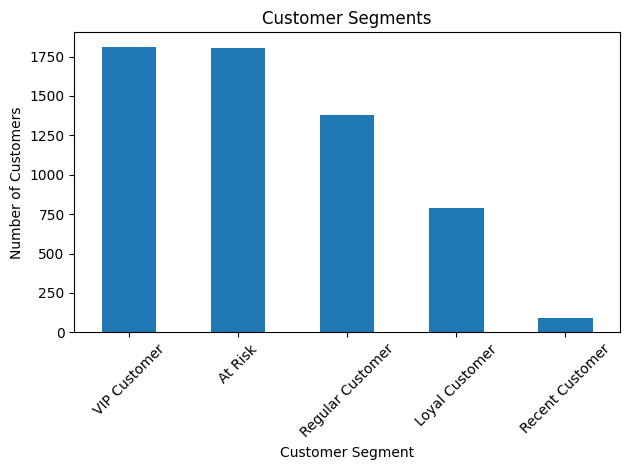

In [61]:
import matplotlib.pyplot as plt

segment_counts = rfm["Customer Segment"].value_counts()

segment_counts.plot(kind="bar")

plt.title("Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [62]:
segment_revenue = (
    rfm.groupby("Customer Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

print(segment_revenue)

Customer Segment
VIP Customer        1.315866e+07
At Risk             2.933647e+06
Loyal Customer      7.733429e+05
Regular Customer    4.792263e+05
Recent Customer     2.992578e+04
Name: Monetary, dtype: float64


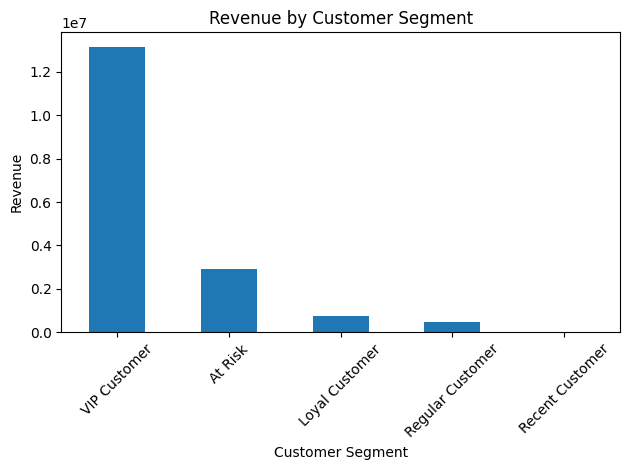

In [63]:
segment_revenue.plot(kind="bar")

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [64]:
rfm.to_csv(
    "../output/customer_analysis_results.csv",
    index=False
)

print("Customer analysis file saved successfully!")

Customer analysis file saved successfully!
